# Trabajo Práctico 2 - Visión por Computadora 1

| Integrante | Legajo |
|---|---|
| Marcos Lund | a2408 |
| Tomás Mc Nally | a2420 |
| Alan Vignolo | a2418 |
| Agustin Biancardi | a2403 |

# TP2 - Clase 3

## Objetivo

Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: `focus_video.mov`.

1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
   1. Medición sobre todo el frame.
   2. Medición sobre una ROI ubicada en el centro del frame. Área de la ROI = 5 o 10% del área total del frame.

   Para cada experimento se debe presentar:
   - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detectó el punto de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

**Puntos extra**: Aplicar unsharp masking para expandir la zona de enfoque y devolver.


### 3.1 Algorithm for image quality measure

**Input:** Image $I$ of size $M \times N$.

**Output:** Image Quality measure (FM) where $FM$ stands for Frequency Domain Image Blur Measure

**Step 1:** Compute $F$ which is the Fourier Transform representation of image $I$

**Step 2:** Find $F_c$ which is obtained by shifting the origin of $F$ to centre.

**Step 3:** Calculate $AF = |F_c|$ where $AF$ is the absolute value of the centered Fourier transform of image $I$.

**Step 4:** Calculate $M = \max(AF)$ where $M$ is the maximum value of the frequency component in $F$.

**Step 5:** Calculate $T_H$ = the total number of pixels in $F$ whose pixel value $>$ *thres*, where $thres = M/1000$.

**Step 6:** Calculate Image Quality measure (FM) from equation (1).

$$\text{Image Quality Measure (FM)} = \frac{T_H}{M \times N} \tag{1}$$


In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def mostrar_imagen(imagen, titulo=''):
    plt.figure(figsize=(7, 4))
    plt.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

In [3]:
def calcular_fm(frame):
    M_rows, N_cols = frame.shape
    
    F = np.fft.fft2(frame) # Transformada de Fourier 2D
    Fc = np.fft.fftshift(F) # Desplazar el componente de frecuencia cero al centro
    AF = np.abs(Fc) # Magnitud de la transformada de Fourier
    MF = np.max(AF) # Máximo de la magnitud
    thres = MF / 1000  # Umbral para considerar un componente de frecuencia como significativo
    TH = np.sum(AF > thres) # Número de componentes de frecuencia que superan el umbral
    FM = TH / (M_rows * N_cols) # Independizamos del tamaño de la imagen
    
    return FM

In [4]:
# Abre el video
video_path = 'focus_video.mov'
captura_video = cv.VideoCapture(video_path)

In [5]:
if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    FM_curve = []
    while True:
        ret, frame = captura_video.read()
        
        if ret:
            frame_gris = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
            FM_curve.append(calcular_fm(frame_gris))
        
        else:
            break

# Libera el objeto de captura de video
captura_video.release()
cv.destroyAllWindows()

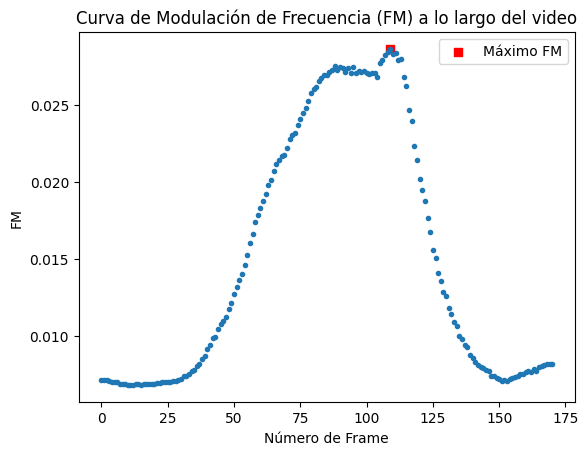

In [6]:
plt.plot(FM_curve, marker='.', linestyle='none')
plt.scatter(x=np.argmax(FM_curve), y=np.max(FM_curve), color='r', label='Máximo FM', marker='s')
plt.title('Curva de Modulación de Frecuencia (FM) a lo largo del video')
plt.xlabel('Número de Frame')
plt.ylabel('FM')
plt.legend()
plt.show()

In [7]:
captura_video = cv.VideoCapture(video_path)

In [8]:
if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    FM_curve_roi = []
    while True:
        ret, frame = captura_video.read()
        
        if ret:
            frame_gris = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
            H, W = frame_gris.shape
            roi_h = int(np.sqrt(0.1) * H)
            roi_w = int(np.sqrt(0.1) * W)
            center_y = H // 2
            center_x = W // 2
            #slicing para obtener el ROI centrado
            frame_gris_roi = frame_gris[center_y - roi_h//2 : center_y + roi_h//2, center_x - roi_w//2 : center_x + roi_w//2]
            FM_curve_roi.append(calcular_fm(frame_gris_roi))
        
        else:
            break

# Libera el objeto de captura de video
captura_video.release()
cv.destroyAllWindows()

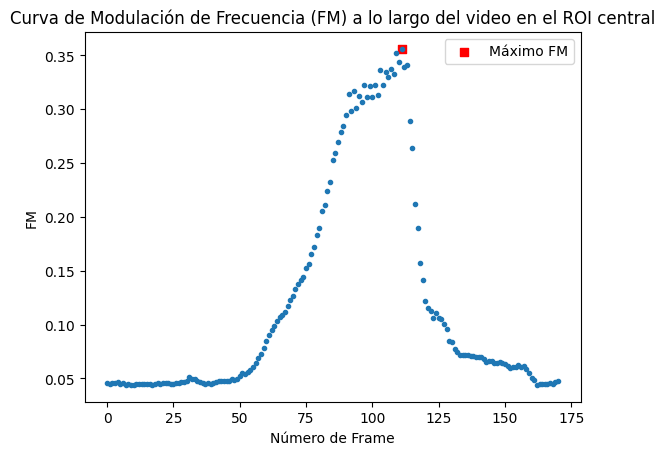

In [9]:
plt.plot(FM_curve_roi, marker='.', linestyle='none')
plt.scatter(x=np.argmax(FM_curve_roi), y=np.max(FM_curve_roi), color='r', label='Máximo FM', marker='s')
plt.title('Curva de Modulación de Frecuencia (FM) a lo largo del video en el ROI central')
plt.xlabel('Número de Frame')
plt.ylabel('FM')
plt.legend()
plt.show()

In [10]:
def unsharp_masking(frame, kernel_size=(5, 5), amount=1.5):
    blurred = cv.GaussianBlur(frame, kernel_size, 0) # Desenfoque gaussiano 
    mask = cv.subtract(frame, blurred) # Mascara = Imagen original - Imagen desenfocada
    sharpened = cv.addWeighted(frame, 1, mask, amount, 0) # Imagen afilada = Imagen original + (Mascara * monto)
    return sharpened

In [11]:
# Abre el video
captura_video = cv.VideoCapture(video_path)
captura_video.set(cv.CAP_PROP_POS_FRAMES, np.argmax(FM_curve)) # Posiciona el video en el frame con el máximo FM

True

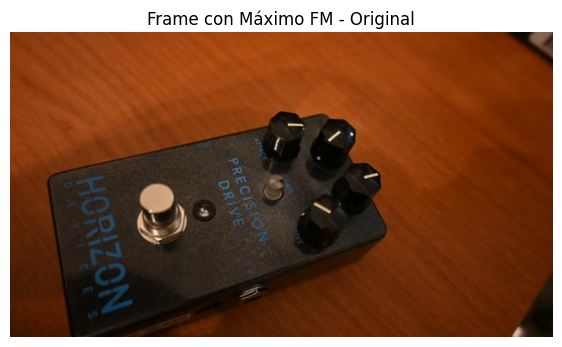

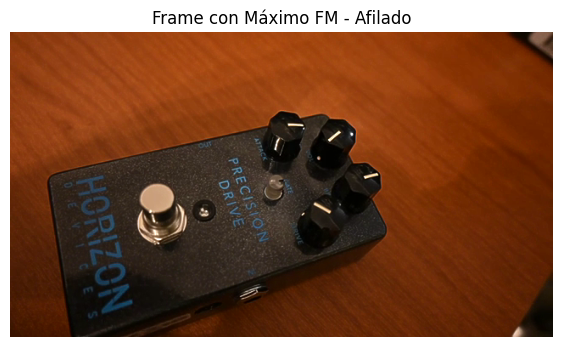

In [12]:
ret, frame = captura_video.read()
frame_sharpened = unsharp_masking(frame)

mostrar_imagen(frame, titulo='Frame con Máximo FM - Original')
mostrar_imagen(frame_sharpened, titulo='Frame con Máximo FM - Afilado')
captura_video.release()
